### load parquet file from huggingface

In [ ]:
from datasets import load_dataset
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
dataset = load_dataset(
    "alizali/trob_images_parquet",
    data_files="1390_entities_dataset_v2.parquet")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# dataset['train'][0]

## Method 1

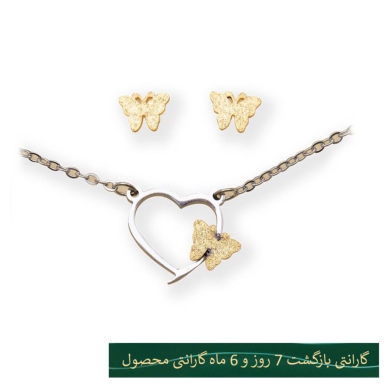

In [ ]:
img_array = np.frombuffer(dataset['train'][0]['array'], dtype=np.uint8).reshape(dataset['train'][0]['shape'])

plt.imshow(img_array)
plt.axis('off')
plt.show()

## Method 2

In [ ]:
def bytes_to_image(row):
    """Convert bytes array back to PIL Image"""
    img_array = np.frombuffer(row['array'], dtype=np.uint8).reshape(row['shape'])

    return img

Filename: l4OiKLkdBaatVjv2.jpg
Shape: [760, 760, 3]


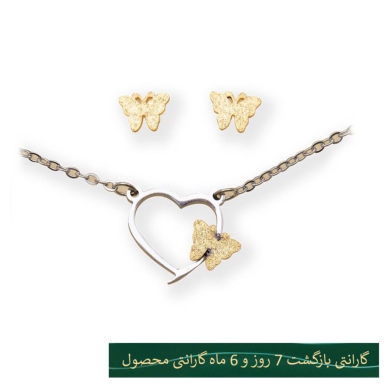

In [ ]:
first_row = dataset['train'][0]
img = bytes_to_image(first_row)

print(f"Filename: {first_row['filename']}")
print(f"Shape: {first_row['shape']}")
plt.imshow(img)
plt.axis('off')
plt.show()

## Method 3

In [ ]:
from huggingface_hub import hf_hub_download
import pandas as pd

In [ ]:
file_path = hf_hub_download(
    repo_id="alizali/torob_images_parquet_resize",
    filename="1390_entities_dataset_v2.parquet",
    repo_type="dataset"
)

1390_entities_dataset_v2.parquet:   0%|          | 0.00/24.4M [00:00<?, ?B/s]

In [ ]:
df = pd.read_parquet(file_path)

In [ ]:
len(df)

256

In [ ]:
df.iloc[0]

,0
filename,l4OiKLkdBaatVjv2.jpg
array,b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff...


In [ ]:
df.iloc[0]['shape']

array([760, 760,   3])

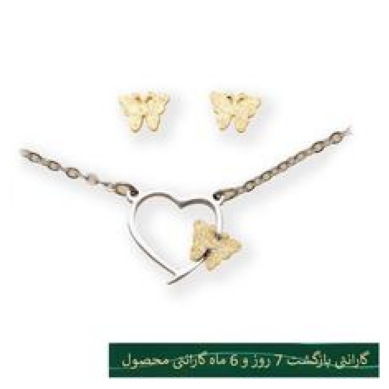

In [ ]:
row = df.iloc[0]
img_array = np.frombuffer(row['array'], dtype=np.uint8).reshape([224, 224, 3])

plt.imshow(img_array)
plt.axis('off')
plt.show()

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [227, 243, 240],
        [252, 255, 255],
        [248, 246, 249]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [247, 255, 255],
        [244, 243, 248],
        [251, 246, 252]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [247, 255, 255],
        [249, 247, 252],
        [255, 251, 255]]], dtype=uint8)
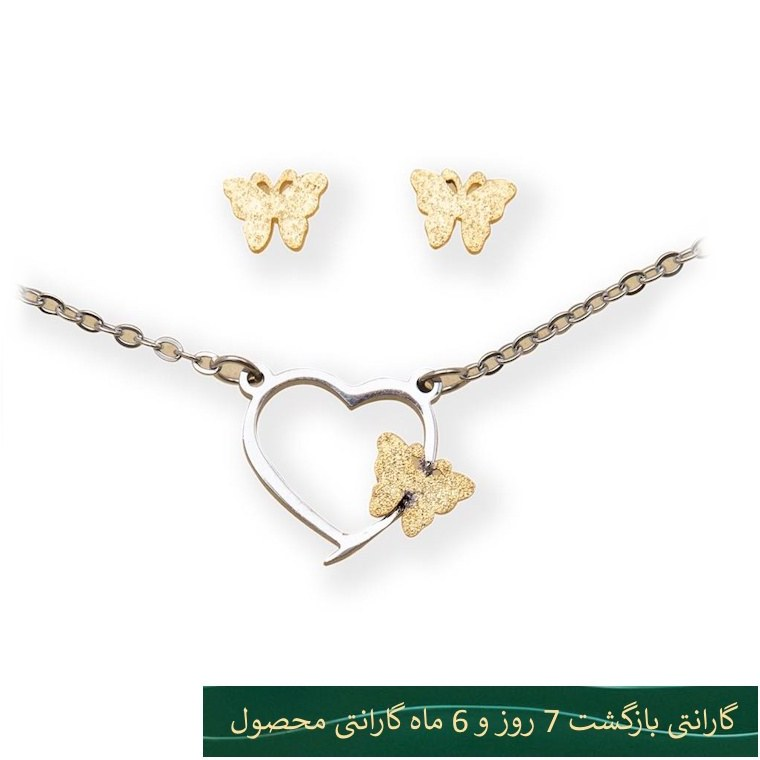

In [ ]:
img_array